In [ ]:
# Add various stellar masses and SFRs to the mock catalogue

In [1]:
import numpy as np
from astropy.table import Table
from astropy.io import fits
import vacmatching as vacm
import matplotlib.pyplot as plt
from astropy.table import join

In [2]:
#Define which mock catalogue we are going to add stellar masses to and which vac files to read them from
reg="N"
obs_seed= 123
sig_lgv = 0.02
min_Vpeak=70.0       #Discard all halos with Vpeak<min_Vpeak. This limits the redshift below which the mock is complete  
N_neigh_vpeak = 1000 #with 1000 the logVpeak scatter among neighbours is < 10^-6 and so will introduce no more than 10^-5 scatter in the magnitude relation
mockcat=rf'./sdata/Mocks/mock_{reg}_seed{obs_seed:3d}_sig_lgv{sig_lgv:.2f}.fits'#file to store resulting mock catalogue
mockcat_out =mockcat.replace('.fits', '_augmented.fits')

#FSF
fsfcat ='/global/cfs/cdirs/desicollab/science/gqp/y3gqp/v1.0/parent/BGS_ANY-y3gqp-parent-fsf-v1.0.fits'

#CIGALE
cigcat ='/global/cfs/cdirs/desicollab/science/gqp/y3gqp/v1.0/st_mass/parent/BGS-y3gqp-parent-v.1.0-cigale-MS-v1.0.fits'




In [3]:
# Read the mock catalogue
mock=Table.read(mockcat)
mock.info('stats')

print('data type of TARGETID:',mock['TARGETID'].dtype)

tid_float = mock['TARGETID']
tid_int   = tid_float.astype(np.int64)

print("Rows:", len(mock))
print("Unique float TARGETIDs:", len(np.unique(tid_float)))
print("Unique int TARGETIDs:", len(np.unique(tid_int)))

<Table length=2850804>
    name        mean        std         min         max    
----------- ----------- ----------- ----------- -----------
         ID 1.47859e+15 2.35687e+14 5.00553e+14 2.08412e+15
        pid 4.07852e+13 7.83754e+13          -1 2.60516e+14
   Mvir_all 6.27622e+12 2.14707e+13 1.14458e+09   1.737e+15
      Vpeak     269.525     141.726     86.0072     2151.14
          x    -228.002     185.622     -1096.6     247.978
          y    -44.9867     285.657    -1106.05     1029.57
          z     455.572     212.679      16.454     1286.65
Mpeak_Scale     0.74971    0.125514    0.162031     0.84235
       dist     597.479     256.634     29.9181      1316.1
        DEC     51.3247     12.2901      32.375     79.2631
         RA     191.274     52.8562     90.3248     298.269
       conc     13.5976     30.2536     1.00039     15196.2
          Z    0.212526   0.0964643   0.0100031    0.499999
       Zobs    0.212581   0.0964217  0.00869347    0.508172
  FracZpeak     0

In [4]:
# Read the required columns from the CIGALE VAC
cig_cols = ['TARGETID', 'LOGM', 'LOGM_ERR', 'LOGSFR', 'LOGSFR_ERR']

with fits.open(cigcat, memmap=True) as hdul:
    data = hdul[1].data
    cig = Table({c: data[c] for c in cig_cols})


cig.info('stats')

<Table length=11263922>
   name        mean        std         min         max    
---------- ----------- ----------- ----------- -----------
  TARGETID 3.96297e+16 2.48703e+12 3.96273e+16 3.96374e+16
      LOGM     10.1953    0.783862           0     12.6312
  LOGM_ERR    0.167342   0.0308367        0.02    0.422966
    LOGSFR   -0.865293     1.51064    -8.94458     3.59706
LOGSFR_ERR     1.42449    0.849203        0.02     3.36138


In [5]:
# Read required columns from the FSF VAC SPECPHOT Table

fsf_cols = ['TARGETID', 'LOGMSTAR', 'LOGMSTAR_IVAR', 'SFR', 'SFR_IVAR']

with fits.open(fsfcat, memmap=True) as hdul:
    data = hdul['SPECPHOT'].data
    fsf = Table({c: data[c] for c in fsf_cols})

#Remove rows with TARGETID=999999
mask=(fsf['TARGETID']!=999999)    
fsf=fsf[mask]
fsf.info('stats')

/global/common/software/desi/perlmutter/desiconda/20260227-2.3.1/conda/lib/python3.13/site-packages/numpy/_core/_methods.py:51: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


<Table length=11263901>
     name         mean        std         min         max    
------------- ----------- ----------- ----------- -----------
     TARGETID 3.96297e+16 2.48703e+12 3.96273e+16 3.96374e+16
     LOGMSTAR     10.3391     0.66141       5.386     13.9358
LOGMSTAR_IVAR     15990.4      170640     7.32934 1.28379e+08
          SFR    0.314695     15.0457 3.20897e-43     40301.4
     SFR_IVAR         inf         inf           0 3.35019e+38


In [6]:
# left join the mock table with the cig and fsf tables using TARGETID as the key
print("Initial:       ", len(mock))

mock = join(mock, cig, keys='TARGETID', join_type='left')
print("After CIG join:", len(mock))

mock = join(mock, fsf, keys='TARGETID', join_type='left')
print("After FSF join:", len(mock))


mock.info('stats')

Initial:        2850804
After CIG join: 2850804
After FSF join: 2850804
<Table length=2850804>
     name         mean        std         min         max     n_bad
------------- ----------- ----------- ----------- ----------- -----
           ID 1.47859e+15 2.35687e+14 5.00553e+14 2.08412e+15     0
          pid 4.07852e+13 7.83754e+13          -1 2.60516e+14     0
     Mvir_all 6.27622e+12 2.14707e+13 1.14458e+09   1.737e+15     0
        Vpeak     269.525     141.726     86.0072     2151.14     0
            x    -228.002     185.622     -1096.6     247.978     0
            y    -44.9867     285.657    -1106.05     1029.57     0
            z     455.572     212.679      16.454     1286.65     0
  Mpeak_Scale     0.74971    0.125514    0.162031     0.84235     0
         dist     597.479     256.634     29.9181      1316.1     0
          DEC     51.3247     12.2901      32.375     79.2631     0
           RA     191.274     52.8562     90.3248     298.269     0
         conc     13.

/global/common/software/desi/perlmutter/desiconda/20260227-2.3.1/conda/lib/python3.13/site-packages/numpy/_core/_methods.py:51: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/global/common/software/desi/perlmutter/desiconda/20260227-2.3.1/conda/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1868: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


In [7]:
# Attempt to find donor objects to assign properties to the objects that do not have a match
# by searching for objects that are close in Z, ABSMAG and restframe colour.
#
print('For CIGALE VAC:')
# Properties to be copied from the selected donor galaxy.
fill_cols_cig = cig_cols[1:]  # we just remove the first column which is TARGETID as we do not need a copy of it
# Define a mask that flags the rows with no match and the rows with LOGM=0 
bad_cig=vacm.find_bad_rows(mock,col='LOGM')
# Find donors and copy properties
mock,donor1_cig=vacm.assign_donors_first_pass(mock,bad_cig,fill_cols_cig,dz=0.02,dmag=0.1,dcol=0.1)

print()
print('For FSF VAC:')
#Now repeat for FSF VAC
fill_cols_fsf = fsf_cols[1:]
# Define a mask that flags the rows with no match and the rows with LOGM=0 
bad_fsf=vacm.find_bad_rows(mock,col='LOGMSTAR')
# Find donors and copy properties
mock,donor1_fsf=vacm.assign_donors_first_pass(mock,bad_fsf,fill_cols_fsf,dz=0.02,dmag=0.1,dcol=0.1)

For CIGALE VAC:
no matching TARGETID:   33
zero_logm: 5,348
Total bad in some way:       5,381
No donor found for 7 objects

For FSF VAC:
no matching TARGETID:   39
zero_logm: 0
Total bad in some way:       39
No donor found for 0 objects


In [8]:
# For the remaining unmatched objects make a second pass to find donors where we keep the dmag and dcol limits 
# but take the object closest in redshift within this magnitude-colour box
mock=vacm.assign_donors_second_pass(mock,bad_cig,fill_cols_cig,dmag=0.1,dcol=0.1)
mock=vacm.assign_donors_second_pass(mock,bad_fsf,fill_cols_fsf,dmag=0.1,dcol=0.1)

After second pass
0  objects that did not have an initial match remain and
0  objects that had a match but had logm=0 remain
After second pass
0  objects that did not have an initial match remain and
0  objects that had a match but had logm=0 remain


In [9]:
# Define a columns of flags that indicate how the matching objects were found
mock=vacm.add_provenance_flags(mock,bad_cig,donor1_cig,flag='cigflag')
mock=vacm.add_provenance_flags(mock,bad_fsf,donor1_fsf,flag='fsfflag')

flag= cigflag
No match found :flag=-1: 0
Matched TARGETID :flag=1: 2845423
Matched col-mag-Z space :flag=2: 5374
Matched in col-mag space and nearest redshift:flag=3: 7
flag= fsfflag
No match found :flag=-1: 0
Matched TARGETID :flag=1: 2850765
Matched col-mag-Z space :flag=2: 39
Matched in col-mag space and nearest redshift:flag=3: 0


Remaining: 0


Text(0, 0.5, 'g-r')

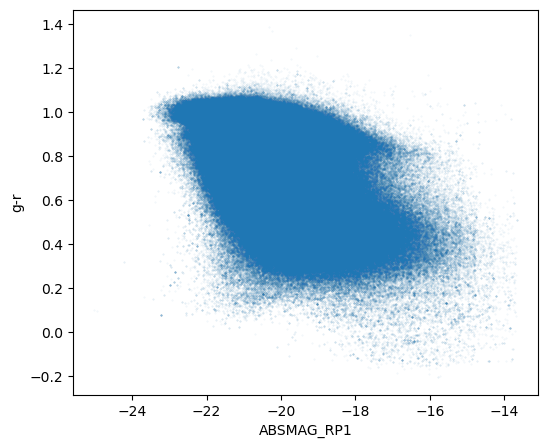

In [10]:
# Scatter plot of the remaining problematic objects for which  no donor could be found.
# It shows they have weird absolute magnitudes probably as a result of an incorrect redshift
good=(mock['cigflag']>0)
remaining= (mock['cigflag']<0)

print("Remaining:", remaining.sum())

colour = mock['ABSMAG_GP1'] - mock['ABSMAG_RP1']

plt.figure(figsize=(6,5))
plt.scatter(
    mock['ABSMAG_RP1'][good],
    colour[good],
    s=0.1,
    alpha=0.1
)

plt.scatter(
    mock['ABSMAG_RP1'][remaining],
    colour[remaining],
    c='red',
    s=20
)

plt.xlabel('ABSMAG_RP1')
plt.ylabel('g-r')

Remaining for which no donor found: 0


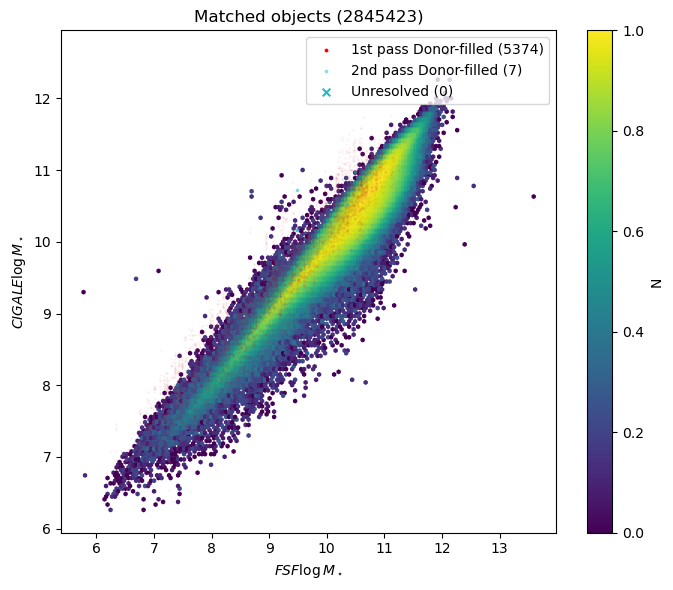

In [11]:
# Plot of FSF stellar mass versus CIGALE stellar mass
# with the objects assigned by the donor process and the objets for which no donor could be found
# overlaid
 


unresolved= (mock['cigflag']<0)
print("Remaining for which no donor found:", unresolved.sum())

second_pass_filled = (mock['cigflag']==3)

matched = (mock['cigflag']==1)
filled_by_donor = (mock['cigflag']==2)

plt.figure(figsize=(7, 6))

plt.hexbin(
    mock['LOGMSTAR'][matched],
    mock['LOGM'][matched],
    gridsize=150,
    bins='log',
    mincnt=1
)


# Objects that received donor values
plt.scatter(
    mock['LOGMSTAR'][filled_by_donor],
    mock['LOGM'][filled_by_donor],
    s=1,
    c='tab:red',
    alpha=0.04
)


# Dummy artist for legend
plt.scatter(
    [], [],
    s=3,
    alpha=1,
    c='red',
    label=f'1st pass Donor-filled ({filled_by_donor.sum()})'
)

# Objects that received donor values
plt.scatter(
    mock['LOGMSTAR'][second_pass_filled],
    mock['LOGM'][second_pass_filled],
    s=3,
    c='tab:cyan',
    alpha=0.4,
    label=f'2nd pass Donor-filled ({second_pass_filled.sum()})'
)


# Remaining unresolved objects
plt.scatter(
    mock['LOGMSTAR'][unresolved],
    np.full(unresolved.sum(), 5),   # arbitrary y-position
    s=30,
    c='tab:cyan',
    marker='x',
    label=f'Unresolved ({unresolved.sum()})'
)

plt.colorbar(label='N')
plt.xlabel(r'$FSF \log M_\star$')
plt.ylabel(r'$CIGALE \log M_\star$')
plt.title(rf'Matched objects ({matched.sum()})')
plt.legend()
plt.tight_layout()
plt.show()

Remaining for which no donor found: 0


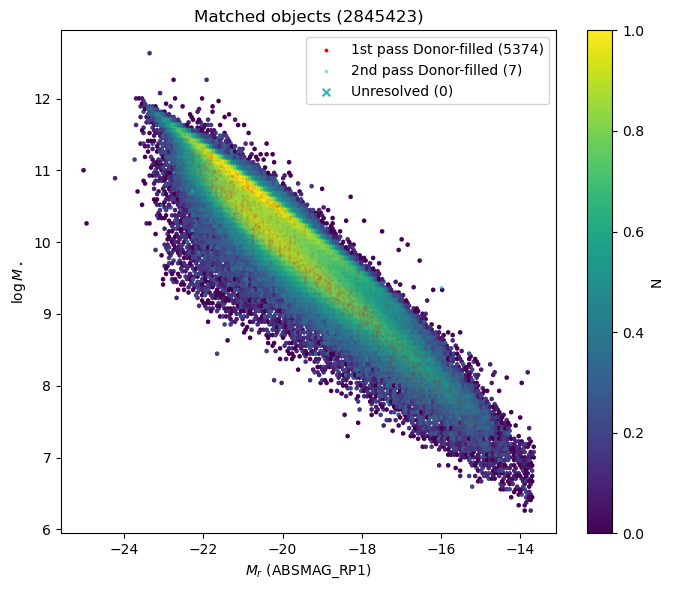

In [12]:
# Plot of absolute magnitude versus stellar mass
# with the objects assigned by the donor process and the objets for which no donor could be found
# overlaid
 


unresolved= (mock['cigflag']<0)
print("Remaining for which no donor found:", unresolved.sum())

second_pass_filled = (mock['cigflag']==3)

matched = (mock['cigflag']==1)
filled_by_donor = (mock['cigflag']==2)

plt.figure(figsize=(7, 6))

plt.hexbin(
    mock['ABSMAG_RP1'][matched],
    mock['LOGM'][matched],
    gridsize=150,
    bins='log',
    mincnt=1
)


# Objects that received donor values
plt.scatter(
    mock['ABSMAG_RP1'][filled_by_donor],
    mock['LOGM'][filled_by_donor],
    s=1,
    c='tab:red',
    alpha=0.04
)


# Dummy artist for legend
plt.scatter(
    [], [],
    s=3,
    alpha=1,
    c='red',
    label=f'1st pass Donor-filled ({filled_by_donor.sum()})'
)

# Objects that received donor values
plt.scatter(
    mock['ABSMAG_RP1'][second_pass_filled],
    mock['LOGM'][second_pass_filled],
    s=3,
    c='tab:cyan',
    alpha=0.4,
    label=f'2nd pass Donor-filled ({second_pass_filled.sum()})'
)


# Remaining unresolved objects
plt.scatter(
    mock['ABSMAG_RP1'][unresolved],
    np.full(unresolved.sum(), 5),   # arbitrary y-position
    s=30,
    c='tab:cyan',
    marker='x',
    label=f'Unresolved ({unresolved.sum()})'
)

plt.colorbar(label='N')
plt.xlabel(r'$M_r$ (ABSMAG_RP1)')
plt.ylabel(r'$\log M_\star$')
plt.title(rf'Matched objects ({matched.sum()})')
plt.legend()
plt.tight_layout()
plt.show()

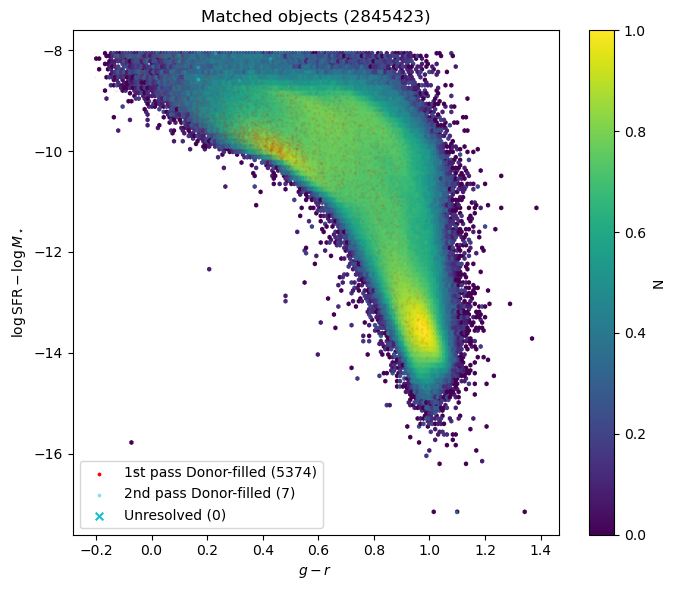

In [13]:
colour = mock['ABSMAG_GP1'] - mock['ABSMAG_RP1']
ssfr_proxy = mock['LOGSFR'] - mock['LOGM']

plt.figure(figsize=(7, 6))

plt.hexbin(
    colour[matched],
    ssfr_proxy[matched],
    gridsize=150,
    bins='log',
    mincnt=1
)



# Objects that received donor values
plt.scatter(
    colour[filled_by_donor],
    ssfr_proxy[filled_by_donor],
    s=1,
    c='tab:red',
    alpha=0.04
)


# Dummy artist for legend
plt.scatter(
    [], [],
    s=3,
    alpha=1,
    c='red',
    label=f'1st pass Donor-filled ({filled_by_donor.sum()})'
)

# Objects that received donor values
plt.scatter(
    colour[second_pass_filled],
    ssfr_proxy[second_pass_filled],
    s=3,
    c='tab:cyan',
    alpha=0.4,
    label=f'2nd pass Donor-filled ({second_pass_filled.sum()})'
)


# Remaining unresolved objects
plt.scatter(
    colour[unresolved],
    np.full(unresolved.sum(), -16),   # arbitrary y-position
    s=30,
    c='tab:cyan',
    marker='x',
    label=f'Unresolved ({unresolved.sum()})'
)

plt.colorbar(label='N')
plt.xlabel(r'$g-r$')
plt.ylabel(r'$\log\mathrm{SFR} - \log M_\star$')
plt.title(rf'Matched objects ({matched.sum()})')
plt.tight_layout()
plt.legend()
plt.show()

/global/common/software/desi/perlmutter/desiconda/20260227-2.3.1/conda/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


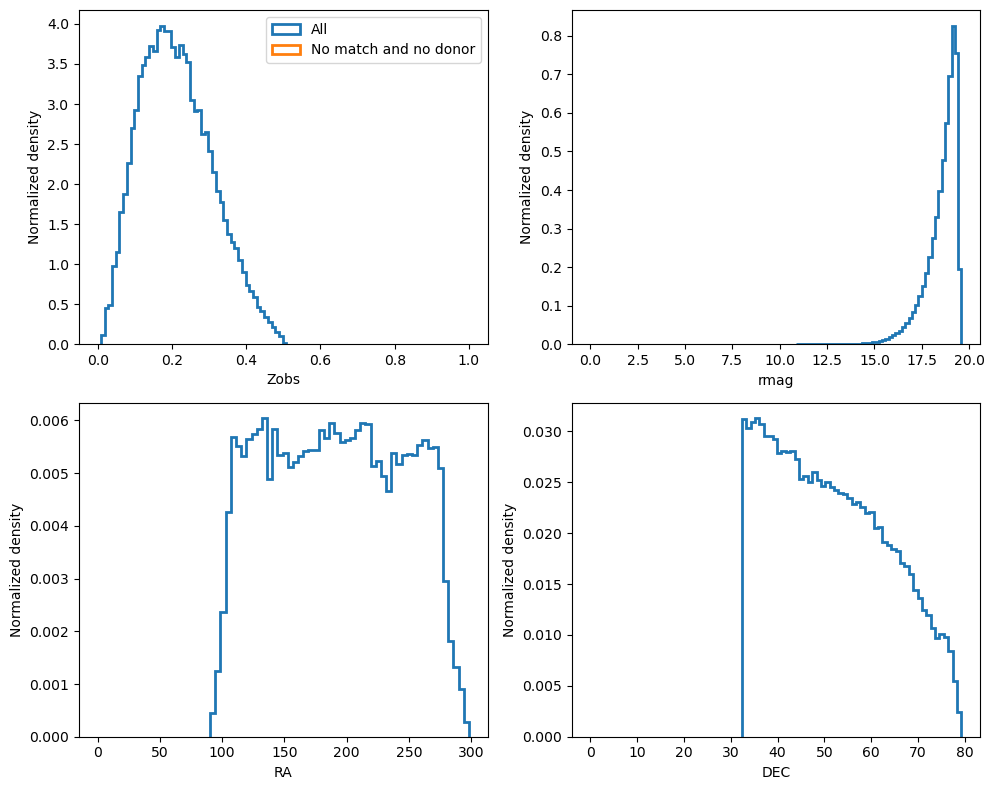

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

cols = ['Zobs', 'rmag', 'RA', 'DEC']

nomatch1= np.isnan(mock['LOGM'])

for ax, col in zip(axes.flat, cols):

    ax.hist(
        mock[col],
        bins=50,
        density=True,
        histtype='step',
        lw=2,
        label='All'
    )

    ax.hist(
        mock[col][nomatch1],
        bins=50,
        density=True,
        histtype='step',
        lw=2,
        label='No match and no donor'
    )

    ax.set_xlabel(col)
    ax.set_ylabel('Normalized density')

axes[0,0].legend()

plt.tight_layout()
plt.show()

In [15]:
#Save the augmented catalogue
mock.write(mockcat_out, overwrite=True)